# Random Forest Classifier On Heart Disease

In [45]:
# Data collection
import pandas as pd

df = pd.read_csv('data_heart_disease.csv')

In [46]:
print(df)

     age  sex   cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1  NaN       145   233    1        0      150      0      2.3   
1     37    1    2       130   250    0        1      187      0      3.5   
2     41    0    1       130   204    0        0      172      0      1.4   
3     56    1    1       120   236    0        1      178      0      0.8   
4     57    0    0       120   354    0        1      163      1      0.6   
..   ...  ...  ...       ...   ...  ...      ...      ...    ...      ...   
298   57    0    0       140   241    0        1      123      1      0.2   
299   45    1    3       110   264    0        1      132      0      1.2   
300   68    1    0       144   193    1        1      141      0      3.4   
301   57    1    0       130   131    0        1      115      1      1.2   
302   57    0    1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   

# Missing values

In [47]:
df.isnull().sum()

age          0
sex          0
cp          10
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
target       0
dtype: int64

##### As the coulmn cp (chest pain) has missing values, we need to impute the data. 

- The data is numeric and hence mean stratergy will be a suitable choice.

In [48]:
from sklearn.impute import SimpleImputer
import numpy as np

# Create the imputer object with the desired strategy
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

# Fit and transform the data
df_imputed = imputer.fit_transform(df)

In [49]:
df = pd.DataFrame(df_imputed, columns=df.columns)
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [50]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,0.965278,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.000000,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.000000,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.000000,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.000000,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57.0,0.0,0.000000,140.0,241.0,0.0,1.0,123.0,1.0,0.2,1.0,0.0,3.0,0.0
299,45.0,1.0,3.000000,110.0,264.0,0.0,1.0,132.0,0.0,1.2,1.0,0.0,3.0,0.0
300,68.0,1.0,0.000000,144.0,193.0,1.0,1.0,141.0,0.0,3.4,1.0,2.0,3.0,0.0
301,57.0,1.0,0.000000,130.0,131.0,0.0,1.0,115.0,1.0,1.2,1.0,1.0,3.0,0.0


# Seperate feature space X and label y

In [51]:
# X = df.iloc[:,:-1]
# y = df.iloc[:,-1]

X = df.drop(columns=['target']) # X = all columns except the target
y = df['target']

In [52]:
# Display X and y

print("X:\n", X)
print("++++++++++++")
print("y:\n", y)

X:
       age  sex        cp  trestbps   chol  fbs  restecg  thalach  exang  \
0    63.0  1.0  0.965278     145.0  233.0  1.0      0.0    150.0    0.0   
1    37.0  1.0  2.000000     130.0  250.0  0.0      1.0    187.0    0.0   
2    41.0  0.0  1.000000     130.0  204.0  0.0      0.0    172.0    0.0   
3    56.0  1.0  1.000000     120.0  236.0  0.0      1.0    178.0    0.0   
4    57.0  0.0  0.000000     120.0  354.0  0.0      1.0    163.0    1.0   
..    ...  ...       ...       ...    ...  ...      ...      ...    ...   
298  57.0  0.0  0.000000     140.0  241.0  0.0      1.0    123.0    1.0   
299  45.0  1.0  3.000000     110.0  264.0  0.0      1.0    132.0    0.0   
300  68.0  1.0  0.000000     144.0  193.0  1.0      1.0    141.0    0.0   
301  57.0  1.0  0.000000     130.0  131.0  0.0      1.0    115.0    1.0   
302  57.0  0.0  1.000000     130.0  236.0  0.0      0.0    174.0    0.0   

     oldpeak  slope   ca  thal  
0        2.3    0.0  0.0   1.0  
1        3.5    0.0  0.0   2.

# split data into train + test

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
# Lets look at size of train and test
print(X_train.shape)
print(X_test.shape)

(242, 13)
(61, 13)


# Modelling and training

In [55]:
from sklearn.ensemble import RandomForestClassifier

model= RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [56]:
# (SKIP)See all the parameters that are used
for key, value in model.get_params().items():
    print(f"{key}: {value}")

bootstrap: True
ccp_alpha: 0.0
class_weight: None
criterion: gini
max_depth: None
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 100
n_jobs: None
oob_score: False
random_state: 42
verbose: 0
warm_start: False


In [57]:
# Lets test on 1 sample
print(list(X.loc[16]))
print(y[16])

[58.0, 0.0, 2.0, 120.0, 340.0, 0.0, 1.0, 172.0, 0.0, 0.0, 2.0, 0.0, 2.0]
1.0


In [58]:
sample = [[58, 0, '2', 120, 340, 0, 1, 172, 0, 0.0, 2, 0, 2]] # actual = 1
X_sample = pd.DataFrame(sample, columns=X.columns)
y_predict = model.predict(X_sample)

print(y_predict)

[1.]


# Evaluate the model: Check the accuracy

In [63]:
from sklearn.metrics import accuracy_score

y_predict = model.predict(X_test)

accuracy = accuracy_score(y_predict, y_test)
print('Accuracy: ',accuracy)

Accuracy:  0.8032786885245902


In [64]:
print("actual :", list(y_test)[:20])
print("predict:", list(y_predict)[:20])

actual : [0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]
predict: [0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0]


In [65]:
# Confusion matrix with raw numbers

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_predict)
print(cm)

[[24  5]
 [ 7 25]]


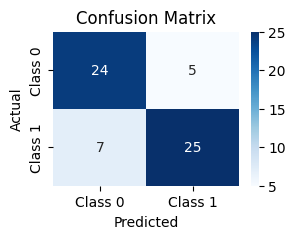

In [66]:
# Plot the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", 
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

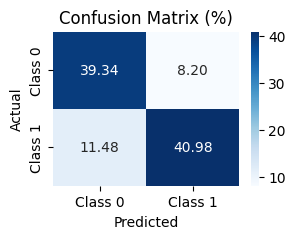

In [67]:
# (OPTIONAL)I want to see the percentage
import numpy as np

cm = confusion_matrix(y_test, y_predict)

# Convert to percentages
cm_percent = cm / np.sum(cm) * 100

# Plot the confusion matrix in percentages
plt.figure(figsize=(3, 2))
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap="Blues", 
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (%)")
plt.show()

### Random forest classifier helped in achieving accuracy upto 85 % which is very good considering the size and quality of data

# RF also shows which features are important for classification

In [71]:
pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)

# You can redo above and use only the top 5 features

oldpeak     0.134281
ca          0.119897
thalach     0.117469
cp          0.099752
thal        0.096695
age         0.092671
exang       0.075022
trestbps    0.074340
chol        0.072038
slope       0.051081
sex         0.036333
restecg     0.020194
fbs         0.010226
dtype: float64

# Hyperparameter tuning: Lets find the best parameter

In [37]:
# Took long time: 4 min.
from sklearn.model_selection import GridSearchCV

# Define the model
rf = RandomForestClassifier(random_state=42)

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # or 'f1', 'precision', etc.
    n_jobs=-1,               # use all CPU cores
    verbose=1
)

# Fit
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=1)

In [39]:
# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_model = grid_search.best_estimator_

# Test accuracy
print("Test Accuracy:", best_model.score(X_test, y_test))

Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Test Accuracy: 0.8852459016393442


## Best model gave higher accuracy: 88.5%